# Options Data EDA — Coincall BTC Options (Jun 17-1500 2026)

Three sections:
1. **Order Book** — coverage, spreads, term structure, update frequency
2. **Trades** — live-only prints (backfill filtered), size, side, price
3. **Joint** — trades matched to contemporaneous OB snapshots


In [1]:
import glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pyarrow.parquet as pq

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

# ── paths ──────────────────────────────────────────────────────────────────
OB_BASE     = "/Volumes/SEAGATE/Crypto/Coincall_OB/options_ob_ws"
TRADES_BASE = "/Volumes/SEAGATE/Crypto/Coincall_OB/options_trades_ws"

# Latest hour only
import os as _os
_ob_hours    = sorted(d for d in _os.listdir(OB_BASE)     if not d.startswith(".") and _os.path.isdir(f"{OB_BASE}/{d}"))
_trade_hours = sorted(d for d in _os.listdir(TRADES_BASE) if not d.startswith(".") and _os.path.isdir(f"{TRADES_BASE}/{d}"))
OB_HOUR     = _ob_hours[-1]
TRADE_HOUR  = _trade_hours[-1]
OB_GLOB     = f"{OB_BASE}/{OB_HOUR}/*.parquet"
TRADES_GLOB = f"{TRADES_BASE}/{TRADE_HOUR}/trades.parquet"
print(f"OB hour:     {OB_HOUR}")
print(f"Trades hour: {TRADE_HOUR}")

MAX_TRADE_AGE_MS = 60_000   # backfill filter: keep only trades received within 60s of their exchange timestamp
OB_MATCH_WINDOW  = 300_000  # joint analysis: max gap (ms) between a trade and its matched OB snapshot

SYM_RE = re.compile(r"^BTCUSD-([0-9]{1,2}[A-Z]{3}[0-9]{2})-([0-9]+)-([CP])$")

def parse_symbol(sym):
    m = SYM_RE.match(str(sym))
    if not m:
        return None, None, None
    exp, strike, cp = m.groups()
    return exp, int(strike), cp

EXPIRY_ORDER = ["16JUN26","17JUN26","18JUN26","19JUN26","20JUN26",
                "26JUN26","3JUL26","31JUL26","28AUG26","25SEP26","25DEC26","26MAR27"]

print("Config ready.")


OB hour:     20260617_1500
Trades hour: 20260617_1500
Config ready.


## 1  Order Book EDA

In [2]:
# Load latest OB hour (one folder, ~300 files — fast)
NUMERIC_COLS = ["bid1_px","bid1_sz","ask1_px","ask1_sz","n_bids","n_asks","server_ts","recv_ts_ms"]

ob_parts = []
for f in sorted(glob.glob(OB_GLOB)):
    if _os.path.basename(f).startswith("._"):
        continue
    t = pq.read_table(f).to_pandas()
    for c in NUMERIC_COLS:
        if c in t.columns:
            t[c] = pd.to_numeric(t[c], errors="coerce")
    ob_parts.append(t)

ob = pd.concat(ob_parts, ignore_index=True)
del ob_parts

ob["recv_dt"]   = pd.to_datetime(ob["recv_ts_ms"], unit="ms", utc=True)
ob["server_dt"] = pd.to_datetime(ob["server_ts"],  unit="ms", utc=True, errors="coerce")
ob[["expiry","strike","cp"]] = ob["symbol"].apply(lambda s: pd.Series(parse_symbol(s)))
ob["spread"]     = ob["ask1_px"] - ob["bid1_px"]
ob["mid"]        = (ob["ask1_px"] + ob["bid1_px"]) / 2
ob["spread_pct"] = ob["spread"] / ob["mid"] * 100

print(f"OB hour: {OB_HOUR}")
print(f"OB rows: {len(ob):,}  |  symbols: {ob['symbol'].nunique()}")
print(f"Time range: {ob['recv_dt'].min()}  →  {ob['recv_dt'].max()}")


OB hour: 20260617_1500
OB rows: 188,308  |  symbols: 294
Time range: 2026-06-17 14:00:14.718000+00:00  →  2026-06-17 15:00:00.226000+00:00


Expiries covered: ['18JUN26', '19JUN26', '20JUN26', '21JUN26', '25DEC26', '25SEP26', '26JUN26', '26MAR27', '28AUG26', '31JUL26', '3JUL26']
Strike range:     59,000 – 71,000
Total OB rows:    188,308
Unique symbols:   294


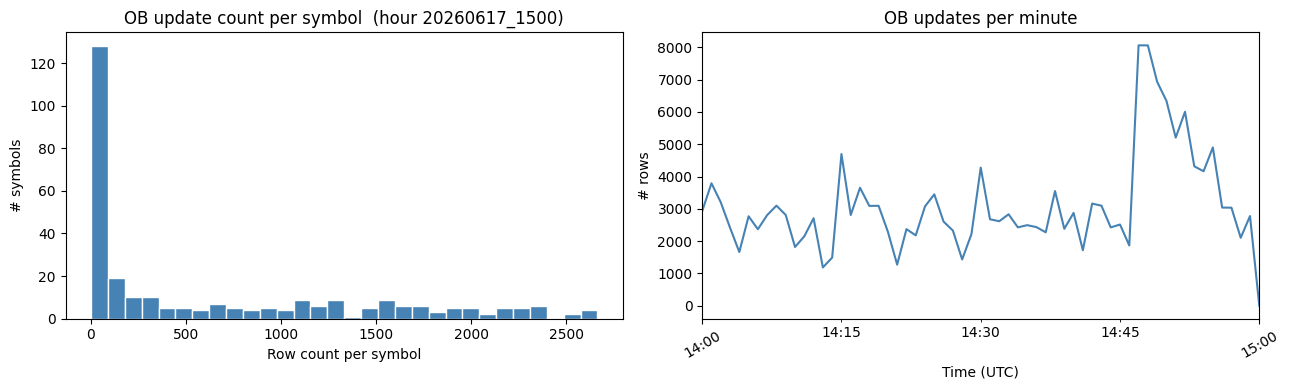

In [3]:
# ── Coverage overview ─────────────────────────────────────────────────────
print(f"Expiries covered: {sorted(ob['expiry'].dropna().unique())}")
print(f"Strike range:     {ob['strike'].min():,} – {ob['strike'].max():,}")
print(f"Total OB rows:    {len(ob):,}")
print(f"Unique symbols:   {ob['symbol'].nunique()}")

# Updates per symbol — distribution
sym_counts = ob["symbol"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(sym_counts.values, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title(f"OB update count per symbol  (hour {OB_HOUR})")
axes[0].set_xlabel("Row count per symbol"); axes[0].set_ylabel("# symbols")

# Updates over time (1-min buckets)
ob["min_bucket"] = ob["recv_dt"].dt.floor("1min")
ob.groupby("min_bucket").size().plot(ax=axes[1], color="steelblue")
axes[1].set_title("OB updates per minute"); axes[1].set_xlabel("Time (UTC)"); axes[1].set_ylabel("# rows")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()


In [4]:
# ── Quote quality ─────────────────────────────────────────────────────────
valid  = ob[(ob["n_bids"] > 0) & (ob["n_asks"] > 0) & ob["bid1_px"].notna() & ob["ask1_px"].notna()]
empty  = ob[(ob["n_bids"] == 0) & (ob["n_asks"] == 0)]

print(f"Valid two-sided quotes : {len(valid):,}  ({len(valid)/len(ob)*100:.1f}%)")
print(f"Empty book snapshots   : {len(empty):,}  ({len(empty)/len(ob)*100:.2f}%)")
print()
print("Book depth (n_bids / n_asks):")
print(pd.DataFrame({
    "n_bids": ob["n_bids"].describe().round(2),
    "n_asks": ob["n_asks"].describe().round(2)
}))


Valid two-sided quotes : 183,085  (97.2%)
Empty book snapshots   : 909  (0.48%)

Book depth (n_bids / n_asks):


          n_bids     n_asks
count  188308.00  188308.00
mean        2.45       2.35
std         0.93       1.03
min         0.00       0.00
25%         2.00       2.00
50%         3.00       2.00
75%         3.00       3.00
max         5.00      15.00


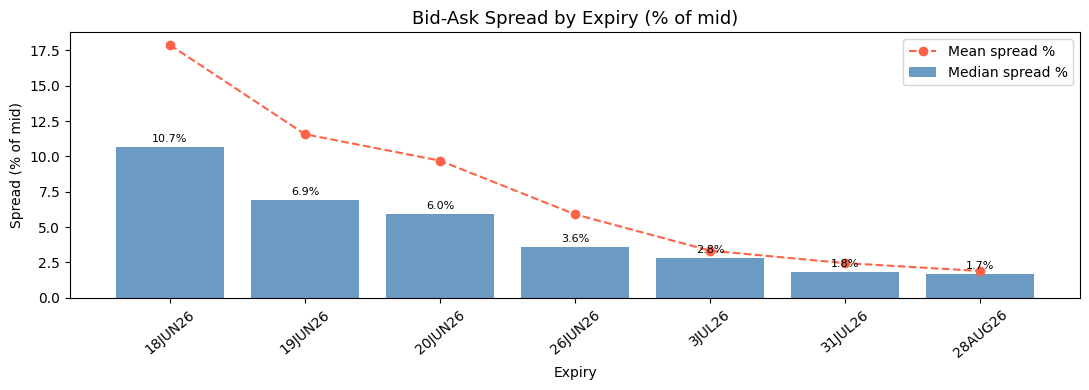


Spread (% mid) by expiry:
          median_%     mean_%  n_rows
expiry                               
18JUN26  10.666667  17.883164   16000
19JUN26   6.933333  11.569912   21245
20JUN26   5.962060   9.700376   24963
26JUN26   3.619910   5.905944   18733
3JUL26    2.836106   3.335759   22784
31JUL26   1.829697   2.453931   27055
28AUG26   1.696713   1.897818   29271


In [5]:
# ── Spread term structure ──────────────────────────────────────────────────
ts = (valid.groupby("expiry")["spread_pct"]
           .agg(["median","mean","count"])
           .reindex([e for e in EXPIRY_ORDER if e in valid["expiry"].unique()])
           .dropna())

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(ts.index, ts["median"], color="steelblue", alpha=0.8, label="Median spread %")
ax.plot(ts.index, ts["mean"], "o--", color="tomato", label="Mean spread %")
ax.set_title("Bid-Ask Spread by Expiry (% of mid)", fontsize=13)
ax.set_ylabel("Spread (% of mid)")
ax.set_xlabel("Expiry")
ax.legend()
ax.tick_params(axis="x", rotation=40)

for bar, (_, row) in zip(bars, ts.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{row['median']:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout(); plt.show()

print("\nSpread (% mid) by expiry:")
print(ts.rename(columns={"count":"n_rows","median":"median_%","mean":"mean_%"}))


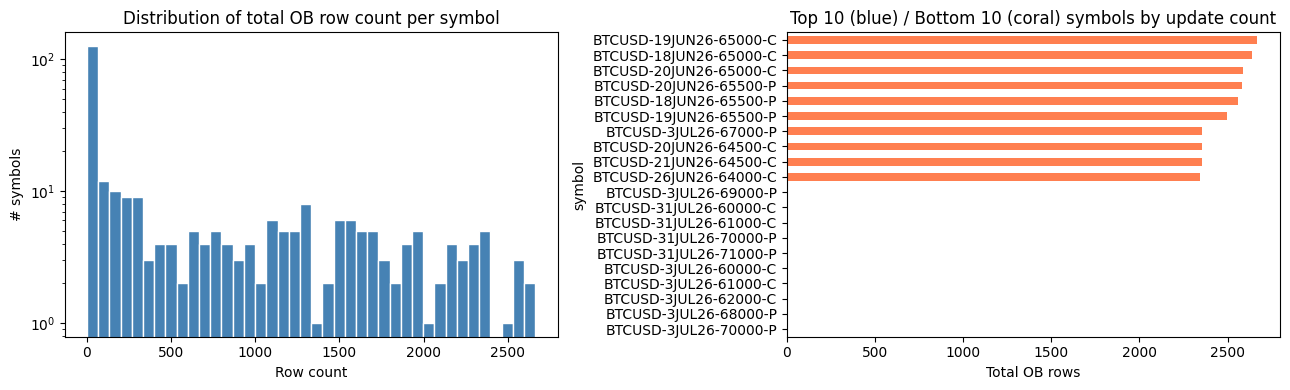

In [6]:
# ── Update frequency per symbol ────────────────────────────────────────────
sym_counts = ob["symbol"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(sym_counts.values, bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of total OB row count per symbol")
axes[0].set_xlabel("Row count"); axes[0].set_ylabel("# symbols")
axes[0].set_yscale("log")

top10 = sym_counts.head(10)
bot10 = sym_counts.tail(10)
combined = pd.concat([top10, bot10]).sort_values()
colors = ["coral"]*10 + ["steelblue"]*10
combined.plot(kind="barh", ax=axes[1], color=colors[::-1])
axes[1].set_title("Top 10 (blue) / Bottom 10 (coral) symbols by update count")
axes[1].set_xlabel("Total OB rows")

plt.tight_layout(); plt.show()


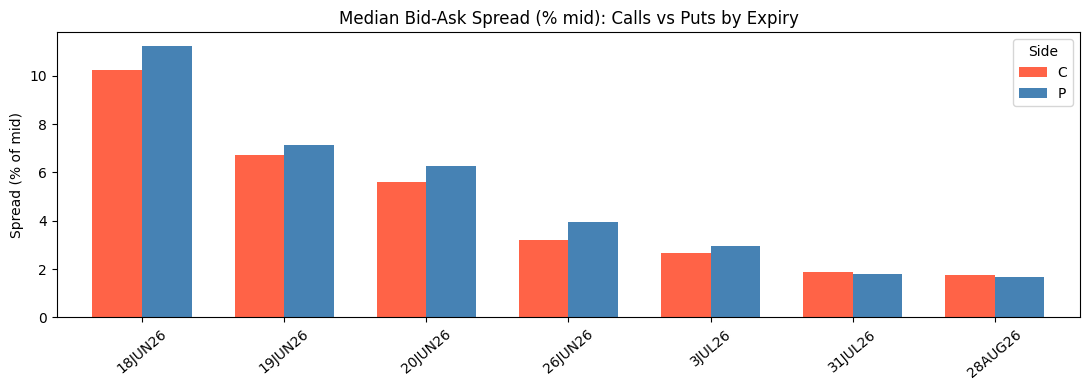

In [7]:
# ── Call vs Put spread by expiry ───────────────────────────────────────────
cp_spread = (valid.groupby(["expiry","cp"])["spread_pct"]
             .median()
             .unstack("cp")
             .reindex([e for e in EXPIRY_ORDER if e in valid["expiry"].unique()])
             .dropna())

ax = cp_spread.plot(kind="bar", figsize=(11,4), color=["tomato","steelblue"], width=0.7)
ax.set_title("Median Bid-Ask Spread (% mid): Calls vs Puts by Expiry")
ax.set_ylabel("Spread (% of mid)"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=40); ax.legend(title="Side")
plt.tight_layout(); plt.show()


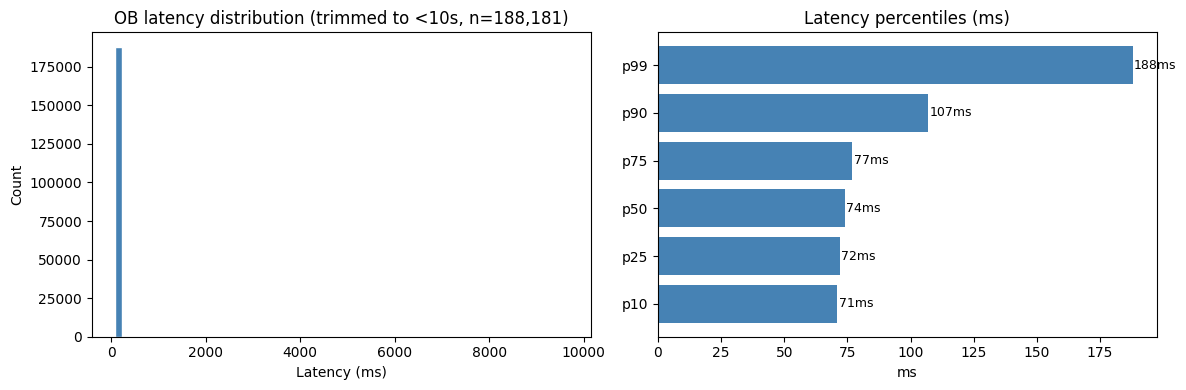

Latency p50=74ms, p99=188ms
Outliers ≥10s: 127 rows (0.067%) — startup reconnect burst, not ongoing


In [8]:
# ── OB network latency (recv_ts_ms – server_ts) ───────────────────────────
lat = (ob["recv_ts_ms"] - ob["server_ts"]).dropna()
lat_clean = lat[lat < 10_000]   # trim extreme outliers for histogram (0.14% of data)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(lat_clean, bins=60, color="steelblue", edgecolor="white")
axes[0].set_title(f"OB latency distribution (trimmed to <10s, n={len(lat_clean):,})")
axes[0].set_xlabel("Latency (ms)"); axes[0].set_ylabel("Count")

p = np.percentile(lat_clean, [10,25,50,75,90,99])
labels = ["p10","p25","p50","p75","p90","p99"]
axes[1].barh(labels, p, color="steelblue")
axes[1].set_title("Latency percentiles (ms)")
axes[1].set_xlabel("ms")
for i,(l,v) in enumerate(zip(labels,p)):
    axes[1].text(v+0.5, i, f"{v:.0f}ms", va="center", fontsize=9)

plt.tight_layout(); plt.show()

outlier_frac = (lat >= 10_000).sum() / len(lat) * 100
print(f"Latency p50={np.median(lat_clean):.0f}ms, p99={np.percentile(lat_clean,99):.0f}ms")
print(f"Outliers ≥10s: {(lat>=10_000).sum()} rows ({outlier_frac:.3f}%) — startup reconnect burst, not ongoing")


## 2  Trades EDA (live prints only)

The `/options/lasttrade` channel pushes up to **30 historical trades** per symbol on every subscribe/reconnect.
We filter these out by keeping only rows where `recv_ts_ms − time ≤ 60s`.
The latency distribution is perfectly bimodal — live prints arrive in <200ms, backfill arrives with latency of hours to weeks, nothing exists between 1s and 1 hour.


In [9]:
# ── Load & filter trades ───────────────────────────────────────────────────
tr_parts = [pd.read_parquet(f) for f in sorted(glob.glob(TRADES_GLOB))]
tr_raw = pd.concat(tr_parts, ignore_index=True) if tr_parts else pd.DataFrame()

tr_raw["latency_ms"] = tr_raw["recv_ts_ms"] - tr_raw["time"]
tr = tr_raw[tr_raw["latency_ms"] <= MAX_TRADE_AGE_MS].copy()
tr = tr.drop_duplicates(subset=["symbol","time"])   # safety dedup across hourly files

tr["dt"]      = pd.to_datetime(tr["time"],       unit="ms", utc=True)
tr["recv_dt"] = pd.to_datetime(tr["recv_ts_ms"], unit="ms", utc=True)
tr[["expiry","strike","cp"]] = tr["symbol"].apply(lambda s: pd.Series(parse_symbol(s)))
tr["notional"] = tr["price"] * tr["qty"]

print(f"Raw rows: {len(tr_raw):,}   Live (filtered): {len(tr):,}   Backfill discarded: {len(tr_raw)-len(tr):,}")
print(f"Time range: {tr['dt'].min()}  →  {tr['dt'].max()}")
print(f"Unique symbols: {tr['symbol'].nunique()}")


Raw rows: 28   Live (filtered): 1   Backfill discarded: 27
Time range: 2026-06-17 14:55:31.052000+00:00  →  2026-06-17 14:55:31.052000+00:00
Unique symbols: 1


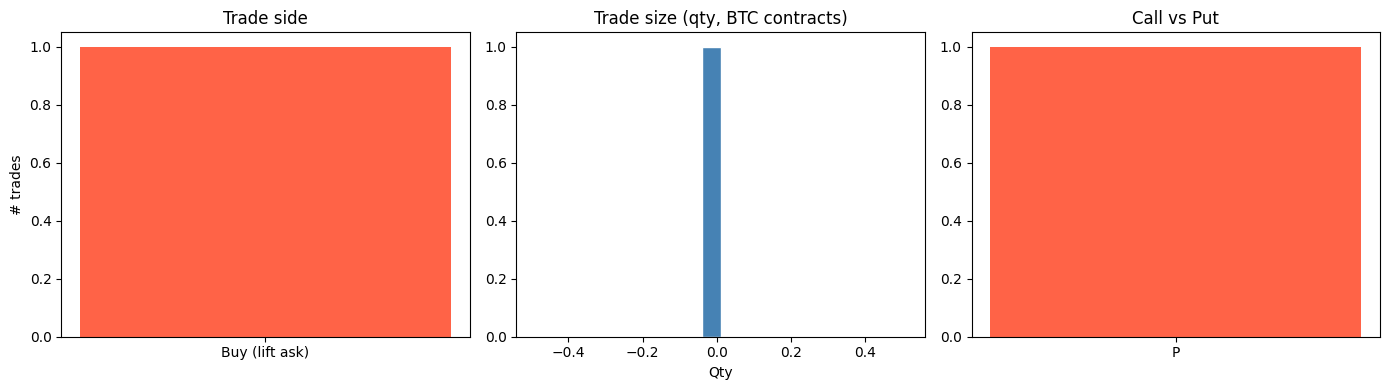


Notional (premium) by symbol:
symbol
BTCUSD-19JUN26-66000-P    10.9
Name: notional, dtype: float64


In [10]:
# ── Trade-side mapping & overview ──────────────────────────────────────────
SIDE_MAP = {1: "Buy (lift ask)", 2: "Sell (hit bid)"}
tr["side_label"] = tr["trade_side"].map(SIDE_MAP).fillna("Unknown")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# side breakdown
side_counts = tr["side_label"].value_counts()
axes[0].bar(side_counts.index, side_counts.values, color=["tomato","steelblue"])
axes[0].set_title("Trade side"); axes[0].set_ylabel("# trades")

# qty distribution
axes[1].hist(tr["qty"], bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Trade size (qty, BTC contracts)")
axes[1].set_xlabel("Qty")

# call vs put
cp_counts = tr["cp"].value_counts()
axes[2].bar(cp_counts.index, cp_counts.values, color=["tomato","steelblue"])
axes[2].set_title("Call vs Put")

plt.tight_layout(); plt.show()

print(f"\nNotional (premium) by symbol:")
print(tr.groupby("symbol")["notional"].sum().sort_values(ascending=False).round(2))


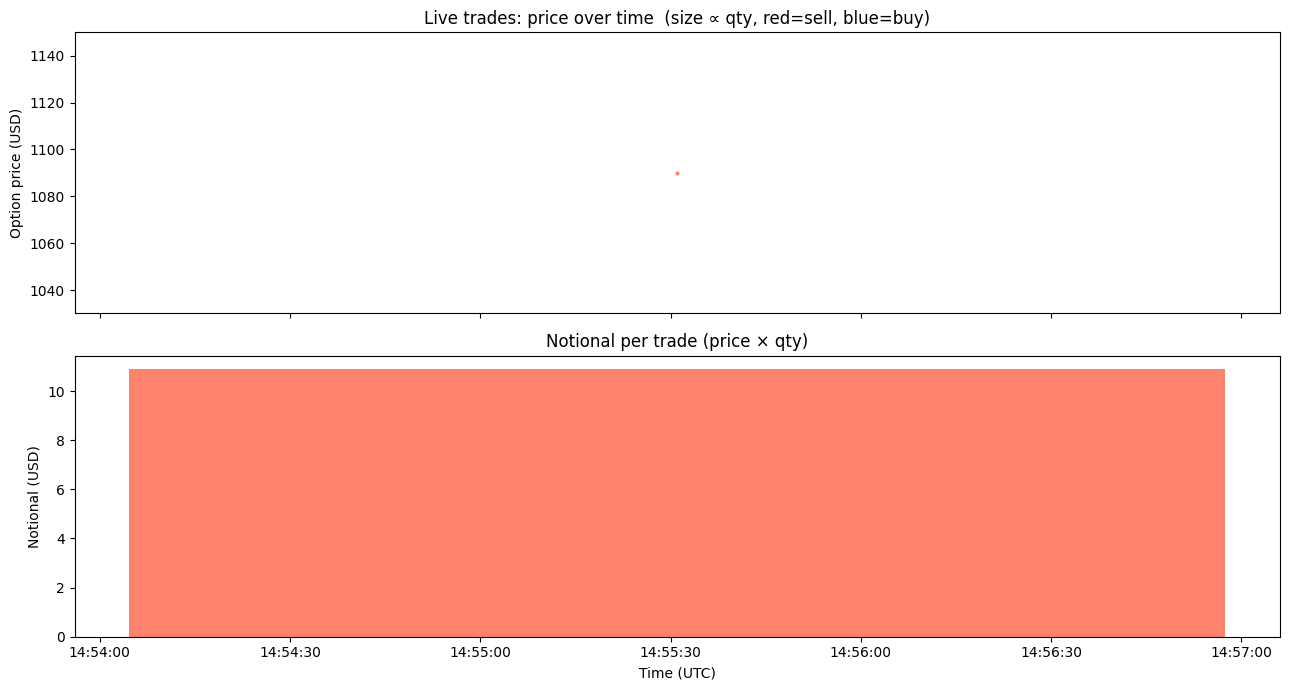

In [11]:
# ── Trade timeline ─────────────────────────────────────────────────────────
colors = tr["trade_side"].map({1:"tomato", 2:"steelblue"}).fillna("grey")

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].scatter(tr["dt"], tr["price"], c=colors, s=tr["qty"]*80+10, alpha=0.8, edgecolors="white", linewidths=0.4)
axes[0].set_title("Live trades: price over time  (size ∝ qty, red=sell, blue=buy)")
axes[0].set_ylabel("Option price (USD)")

axes[1].bar(tr["dt"], tr["notional"], width=0.002, color=colors, alpha=0.8)
axes[1].set_title("Notional per trade (price × qty)")
axes[1].set_ylabel("Notional (USD)"); axes[1].set_xlabel("Time (UTC)")

plt.tight_layout(); plt.show()


## 3  Joint Analysis — Trades Matched to Contemporaneous OB

For each live trade we find the **most recent OB snapshot** for the same symbol with `recv_ts_ms ≤ trade recv_ts_ms`.
We only retain matches where the gap is ≤ `OB_MATCH_WINDOW` (5 min), ensuring the quote reflects the market state at trade time.

Key questions:
- Was the trade at the bid, ask, or inside the spread?
- What was the effective spread vs quoted spread?
- Do larger trades tend to be more aggressive (hit mid or through)?


In [12]:
# ── Match each live trade to its most recent OB snapshot ──────────────────
# merge_asof requires the 'on' key to be globally sorted in both frames.
# We rename ob's recv_ts_ms → ob_recv_ts_ms so the key survives the join and
# we can compute the match gap directly.

ob_cols = ["symbol","recv_ts_ms","bid1_px","bid1_sz","ask1_px","ask1_sz","mid","spread","spread_pct"]
ob_join = (valid[ob_cols]
           .rename(columns={"recv_ts_ms": "ob_recv_ts_ms"})
           .sort_values("ob_recv_ts_ms")        # global sort required by merge_asof
           .reset_index(drop=True))

tr_join = tr.sort_values("recv_ts_ms").reset_index(drop=True)  # global sort on key

matched = pd.merge_asof(
    tr_join,
    ob_join.rename(columns={c: f"ob_{c}" for c in ob_join.columns if c not in ("symbol","ob_recv_ts_ms")}),
    left_on="recv_ts_ms",
    right_on="ob_recv_ts_ms",
    by="symbol",
    direction="backward",
)

matched["ob_gap_ms"] = matched["recv_ts_ms"] - matched["ob_recv_ts_ms"]

# Only keep trades with a contemporaneous OB snapshot within the match window
m = matched[matched["ob_gap_ms"] <= OB_MATCH_WINDOW].copy()

print(f"Live trades:        {len(tr)}")
print(f"Matched to OB:      {len(m)}  (gap ≤ {OB_MATCH_WINDOW/1000:.0f}s)")
print(f"No OB match:        {len(matched) - len(m)}")
print(f"\nOB gap (ms) stats:"); print(m["ob_gap_ms"].describe().round(1))


Live trades:        1
Matched to OB:      1  (gap ≤ 300s)
No OB match:        0

OB gap (ms) stats:
count      1.0
mean     138.0
std        NaN
min      138.0
25%      138.0
50%      138.0
75%      138.0
max      138.0
Name: ob_gap_ms, dtype: float64


In [13]:
# ── Trade price relative to prevailing quote ───────────────────────────────
m["price_vs_mid"]  = m["price"] - m["ob_mid"]
m["price_vs_mid_pct"] = m["price_vs_mid"] / m["ob_mid"] * 100

# Classify: at bid, at ask, inside spread, outside spread
def classify_trade(row):
    if pd.isna(row["ob_bid1_px"]) or pd.isna(row["ob_ask1_px"]):
        return "no_quote"
    tol = 1.0   # $1 tolerance for "at bid/ask"
    if abs(row["price"] - row["ob_ask1_px"]) <= tol:
        return "at ask (buy)"
    elif abs(row["price"] - row["ob_bid1_px"]) <= tol:
        return "at bid (sell)"
    elif row["ob_bid1_px"] < row["price"] < row["ob_ask1_px"]:
        return "inside spread"
    else:
        return "outside spread"

m["price_location"] = m.apply(classify_trade, axis=1)

print("Trade price location relative to prevailing quote:")
print(m["price_location"].value_counts())
print()
print(m[["symbol","dt","price","ob_bid1_px","ob_ask1_px","ob_mid","price_vs_mid_pct","price_location",
         "qty","side_label","ob_gap_ms"]].to_string())


Trade price location relative to prevailing quote:
price_location
at ask (buy)    1
Name: count, dtype: int64

                   symbol                               dt   price  ob_bid1_px  ob_ask1_px  ob_mid  price_vs_mid_pct price_location   qty      side_label  ob_gap_ms
0  BTCUSD-19JUN26-66000-P 2026-06-17 14:55:31.052000+00:00  1090.0      1040.0      1090.0  1065.0          2.347418   at ask (buy)  0.01  Buy (lift ask)        138


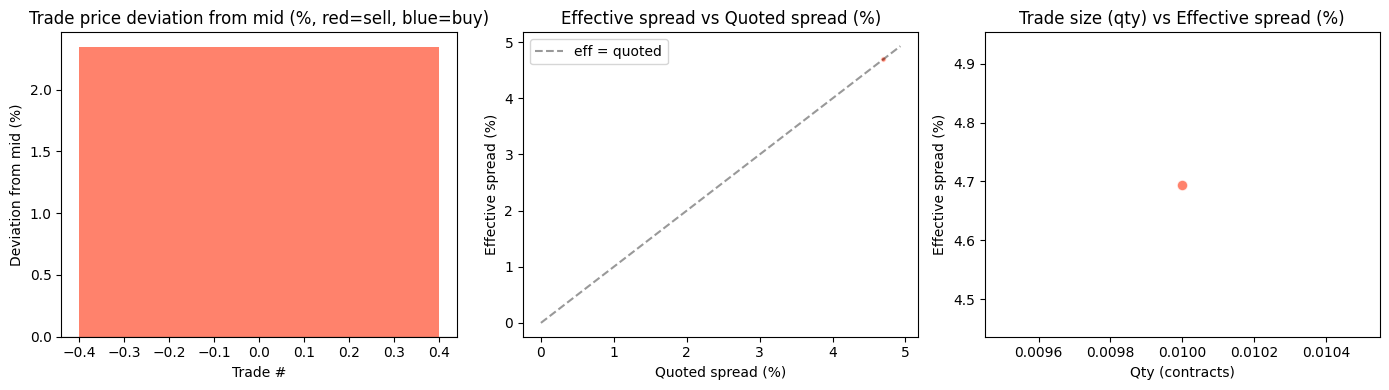


Effective spread (% mid)  — mean: 4.69%  median: 4.69%
Quoted spread (% mid)     — mean: 4.69%  median: 4.69%

Eff/Quoted ratio > 1 (paid through quoted spread): 0/1


In [14]:
# ── Effective spread vs quoted spread ──────────────────────────────────────
# Effective spread = 2 * |trade_price - mid| / mid  (signed: positive = paid above mid)
m["eff_spread_pct"] = 2 * m["price_vs_mid_pct"].abs()
m["eff_vs_quoted"]  = m["eff_spread_pct"] / m["ob_spread_pct"]   # >1 = worse than quoted

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# price deviation from mid
colors = m["trade_side"].map({1:"tomato",2:"steelblue"}).fillna("grey")
axes[0].bar(range(len(m)), m["price_vs_mid_pct"], color=colors, alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Trade price deviation from mid (%, red=sell, blue=buy)")
axes[0].set_xlabel("Trade #"); axes[0].set_ylabel("Deviation from mid (%)")

# effective vs quoted spread
axes[1].scatter(m["ob_spread_pct"], m["eff_spread_pct"],
                c=colors, s=m["qty"]*80+15, alpha=0.8, edgecolors="white")
lim = max(m["ob_spread_pct"].max(), m["eff_spread_pct"].max()) * 1.05
axes[1].plot([0,lim],[0,lim], "k--", alpha=0.4, label="eff = quoted")
axes[1].set_title("Effective spread vs Quoted spread (%)")
axes[1].set_xlabel("Quoted spread (%)"); axes[1].set_ylabel("Effective spread (%)")
axes[1].legend()

# trade size vs effective spread
axes[2].scatter(m["qty"], m["eff_spread_pct"], c=colors, s=60, alpha=0.8, edgecolors="white")
axes[2].set_title("Trade size (qty) vs Effective spread (%)")
axes[2].set_xlabel("Qty (contracts)"); axes[2].set_ylabel("Effective spread (%)")

plt.tight_layout(); plt.show()

print(f"\nEffective spread (% mid)  — mean: {m['eff_spread_pct'].mean():.2f}%  median: {m['eff_spread_pct'].median():.2f}%")
print(f"Quoted spread (% mid)     — mean: {m['ob_spread_pct'].mean():.2f}%  median: {m['ob_spread_pct'].median():.2f}%")
print(f"\nEff/Quoted ratio > 1 (paid through quoted spread): {(m['eff_vs_quoted']>1).sum()}/{len(m)}")


In [15]:
# ── Summary table ──────────────────────────────────────────────────────────
summary = (m.groupby("symbol")
            .agg(
                n_trades=("price","count"),
                total_qty=("qty","sum"),
                total_notional=("notional","sum"),
                avg_eff_spread_pct=("eff_spread_pct","mean"),
                avg_quoted_spread_pct=("ob_spread_pct","mean"),
                buy_count=("trade_side", lambda x: (x==2).sum()),
                sell_count=("trade_side", lambda x: (x==1).sum()),
            )
            .sort_values("total_notional", ascending=False))

print("Per-symbol summary (matched trades):")
print(summary.round(2))


Per-symbol summary (matched trades):
                        n_trades  total_qty  total_notional  avg_eff_spread_pct  avg_quoted_spread_pct  buy_count  sell_count
symbol                                                                                                                       
BTCUSD-19JUN26-66000-P         1       0.01            10.9                4.69                   4.69          0           1
